<a href="https://colab.research.google.com/github/SagarMahata/Tea-Leaves-Disease-Detector/blob/main/Newleaves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['gate', 'C LANGUAGE', 'Untitled document (2).gdoc', 'Colab Notebooks', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'Resume.gdoc', 'Sagar_Mahata_Resume.gdoc', 'Sagar_Mahata_Resume (1) (2).gdoc', 'Sagar_Mahata_Resume (1) (1).gdoc', 'Sagar_Mahata_Resume (1).gdoc', 'DOC-20260918-WA0012.gdoc', 'Tea_Leaf_Dataset']


In [ ]:
drive_path = "/content/drive/MyDrive/Tea_Leaf_Dataset"

print(os.listdir(drive_path))

['TLDB.zip']


In [ ]:
zip_path = "/content/drive/MyDrive/TLDB.zip"

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Tea_Leaf_Dataset/TLDB.zip"
extract_path = "/content/TLDB"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
import os

for root, dirs, files in os.walk("/content/TLDB"):
    print(root, "->", len(files), "files")

/content/TLDB -> 0 files
/content/TLDB/TeaLeafDiseaseBD Annotated smartphone images and l -> 6 files


In [ ]:
for item in os.listdir("/content/TLDB"):
    full_path = os.path.join("/content/TLDB", item)

    if os.path.isdir(full_path):
        print("FOLDER:", item)
    else:
        print("FILE:", item)

FOLDER: TeaLeafDiseaseBD Annotated smartphone images and l


In [ ]:
import os

path = "/content/TLDB/TeaLeafDiseaseBD Annotated smartphone images and l"

for item in os.listdir(path):
    full_path = os.path.join(path, item)

    if os.path.isdir(full_path):
        print("FOLDER:", item)
    else:
        print("FILE:", item)

FILE: Data Collection Pipeline.png
FILE: README.md
FILE: TeaLeafDiseaseBD.zip
FILE: Mendeley_Record.png
FILE: Dataset metadata.csv
FILE: Annotation protocol.pdf


In [ ]:
for root, dirs, files in os.walk(path):
    image_count = sum(
        1 for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    if image_count > 0:
        print(root, "→", image_count, "images")

/content/TLDB/TeaLeafDiseaseBD Annotated smartphone images and l → 2 images


In [ ]:
import zipfile
import os

inner_zip = "/content/TLDB/TeaLeafDiseaseBD Annotated smartphone images and l/TeaLeafDiseaseBD.zip"

actual_dataset = "/content/TeaLeafDataset"

os.makedirs(actual_dataset, exist_ok=True)

with zipfile.ZipFile(inner_zip, "r") as zip_ref:
    zip_ref.extractall(actual_dataset)

print("Actual dataset extracted!")

Actual dataset extracted!


In [ ]:
dataset_path = "/content/TeaLeafDataset/TeaLeafDiseaseBD/TeaLeafDiseaseBD/root/TeaLeafDataset/Original images"

print(dataset_path)

/content/TeaLeafDataset/TeaLeafDiseaseBD/TeaLeafDiseaseBD/root/TeaLeafDataset/Original images


In [ ]:
import os

print(os.listdir(dataset_path))

['Algal leaf spot', 'Healthy', 'Red Rust', 'Gray Blight', 'Helopelties', 'Brown Blight', 'Red Spider']


In [ ]:
from PIL import Image
import os

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(class_name, ":", len(images))

Algal leaf spot : 1799
Healthy : 1782
Red Rust : 2131
Gray Blight : 1949
Helopelties : 1879
Brown Blight : 1957
Red Spider : 1588


In [ ]:
import os
import shutil
import random

output_dir = "/content/tea_vit"

random.seed(42)

for split in ["train", "val", "test"]:
    os.makedirs(
        os.path.join(output_dir, split),
        exist_ok=True
    )

In [ ]:
for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)

    n = len(images)

    train_end = int(0.70 * n)
    val_end = int(0.85 * n)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for split, split_images in [
        ("train", train_images),
        ("val", val_images),
        ("test", test_images)
    ]:

        destination = os.path.join(
            output_dir,
            split,
            class_name
        )

        os.makedirs(destination, exist_ok=True)

        for image in split_images:

            shutil.copy(
                os.path.join(class_path, image),
                os.path.join(destination, image)
            )

print("Dataset split completed!")

Dataset split completed!


In [ ]:
for split in ["train", "val", "test"]:

    print("\n", split.upper())

    split_path = os.path.join(output_dir, split)

    total = 0

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        total += count

        print(class_name, ":", count)

    print("Total:", total)


 TRAIN
Algal leaf spot : 1259
Healthy : 1247
Red Rust : 1491
Gray Blight : 1364
Helopelties : 1315
Brown Blight : 1369
Red Spider : 1111
Total: 9156

 VAL
Algal leaf spot : 270
Healthy : 267
Red Rust : 320
Gray Blight : 292
Helopelties : 282
Brown Blight : 294
Red Spider : 238
Total: 1963

 TEST
Algal leaf spot : 270
Healthy : 268
Red Rust : 320
Gray Blight : 293
Helopelties : 282
Brown Blight : 294
Red Spider : 239
Total: 1966


In [ ]:
!pip install -q timm

In [ ]:
import torch
import torchvision
import timm
import os

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("timm:", timm.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
timm: 1.0.29
Device: cuda
GPU: Tesla T4


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [ ]:
from torchvision import datasets
import os

output_dir = "/content/tea_vit"

train_dataset = datasets.ImageFolder(
    os.path.join(output_dir, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(output_dir, "val"),
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(output_dir, "test"),
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nClasses:")
print(train_dataset.classes)

Train: 9156
Validation: 1963
Test: 1966

Classes:
['Algal leaf spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopelties', 'Red Rust', 'Red Spider']


In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created!")

DataLoaders created!


In [ ]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([5, 1, 2, 2, 6, 6, 0, 3, 5, 3])


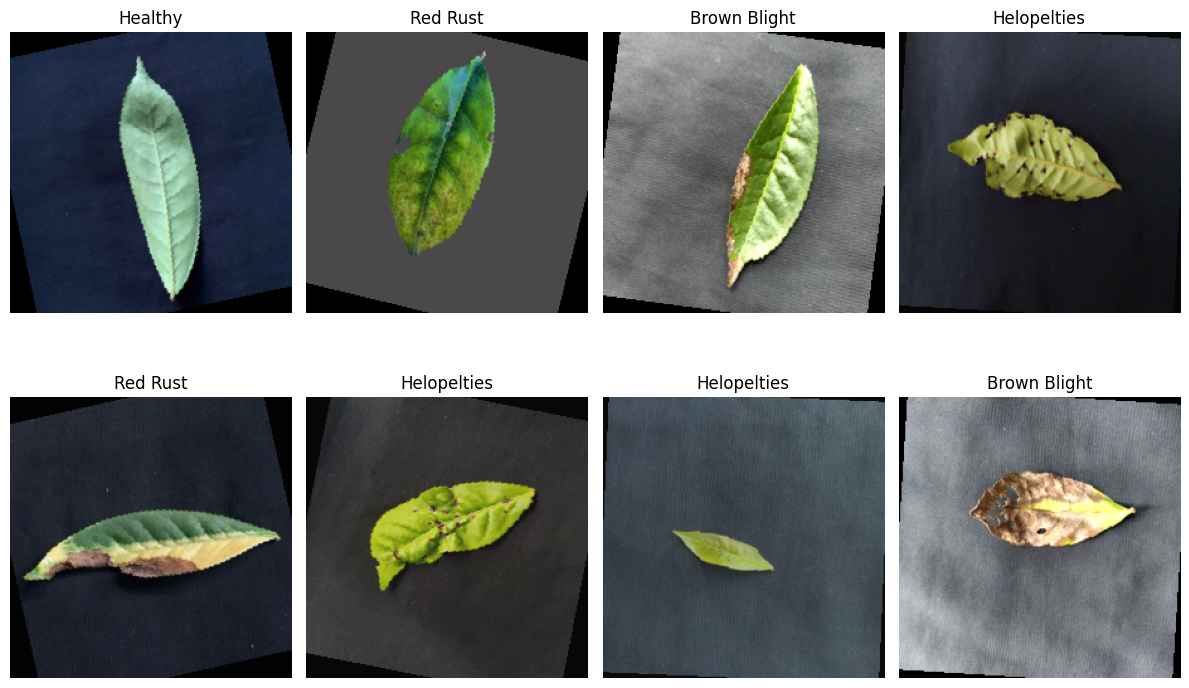

In [ ]:
import matplotlib.pyplot as plt
import torch

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    image = images[i].permute(1, 2, 0)

    # Undo ImageNet normalization
    image = image * torch.tensor(
        [0.229, 0.224, 0.225]
    ) + torch.tensor(
        [0.485, 0.456, 0.406]
    )

    image = torch.clamp(image, 0, 1)

    plt.imshow(image)

    plt.title(train_dataset.classes[labels[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=len(train_dataset.classes)
)

model = model.to(device)

print("Number of classes:", len(train_dataset.classes))

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Number of classes: 7


In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 7])


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

print("Loss function and optimizer ready.")

Loss function and optimizer ready.


In [ ]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

print("Scheduler ready.")

Scheduler ready.


In [ ]:
num_epochs = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(num_epochs):

    # TRAINING

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total


    # VALIDATION

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_accuracy = 100 * val_correct / val_total


    # LEARNING RATE

    scheduler.step()


    # SAVE RESULTS

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # SAVE BEST MODEL

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "/content/best_tea_vit.pth"
        )

        print("Best model saved!")


    # PRINT RESULTS

    print(
        f"\nEpoch [{epoch+1}/{num_epochs}]"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_accuracy:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_accuracy:.2f}%"
    )

    print(
        f"Learning Rate: "
        f"{optimizer.param_groups[0]['lr']:.7f}"
    )

print("\nTraining completed!")
print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

Best model saved!

Epoch [1/10]
Train Loss: 0.3224
Train Accuracy: 89.35%
Validation Loss: 0.1849
Validation Accuracy: 93.17%
Learning Rate: 0.0000293
Best model saved!

Epoch [2/10]
Train Loss: 0.1243
Train Accuracy: 96.02%
Validation Loss: 0.1451
Validation Accuracy: 95.57%
Learning Rate: 0.0000271
Best model saved!

Epoch [3/10]
Train Loss: 0.0866
Train Accuracy: 97.25%
Validation Loss: 0.1282
Validation Accuracy: 95.67%
Learning Rate: 0.0000238
Best model saved!

Epoch [4/10]
Train Loss: 0.0571
Train Accuracy: 98.22%
Validation Loss: 0.1263
Validation Accuracy: 95.87%
Learning Rate: 0.0000196
Best model saved!

Epoch [5/10]
Train Loss: 0.0483
Train Accuracy: 98.45%
Validation Loss: 0.1101
Validation Accuracy: 96.94%
Learning Rate: 0.0000150

Epoch [6/10]
Train Loss: 0.0212
Train Accuracy: 99.18%
Validation Loss: 0.1306
Validation Accuracy: 96.64%
Learning Rate: 0.0000104

Epoch [7/10]
Train Loss: 0.0176
Train Accuracy: 99.31%
Validation Loss: 0.1119
Validation Accuracy: 96.69%
Lear

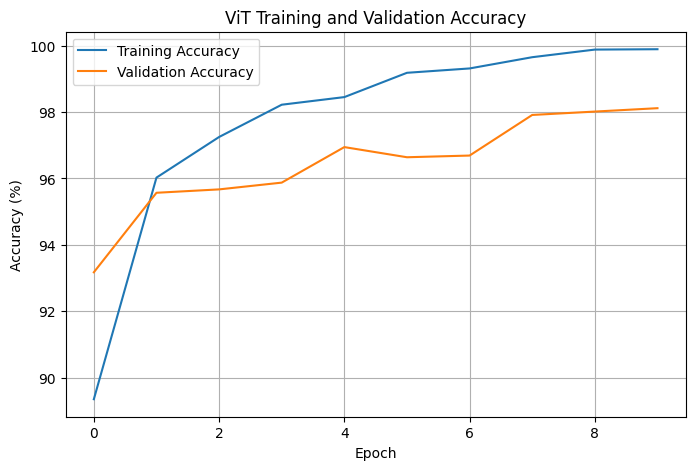

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ViT Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()

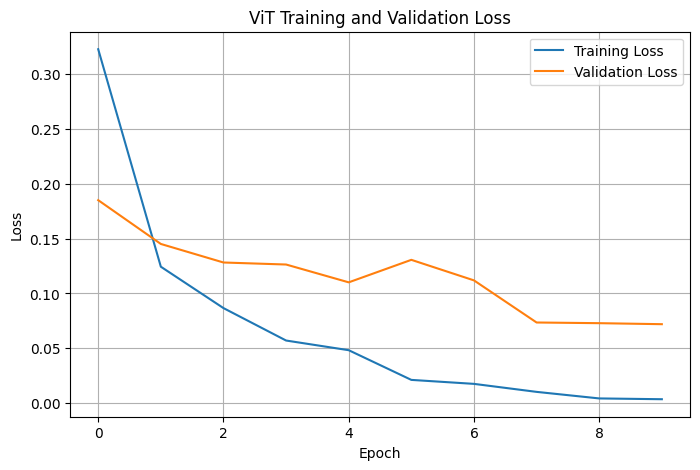

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ViT Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/best_tea_vit.pth",
        map_location=device
    )
)

model = model.to(device)

print(
    f"Loaded best model with "
    f"validation accuracy: {best_val_accuracy:.2f}%"
)

Loaded best model with validation accuracy: 98.12%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 98.07%


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Classification report
print(classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    digits=4
))

                 precision    recall  f1-score   support

Algal leaf spot     0.9665    0.9630    0.9647       270
   Brown Blight     0.9965    0.9796    0.9880       294
    Gray Blight     0.9635    0.9898    0.9764       293
        Healthy     0.9815    0.9925    0.9870       268
    Helopelties     0.9928    0.9823    0.9875       282
       Red Rust     0.9875    0.9875    0.9875       320
     Red Spider     0.9747    0.9665    0.9706       239

       accuracy                         0.9807      1966
      macro avg     0.9804    0.9802    0.9803      1966
   weighted avg     0.9808    0.9807    0.9807      1966



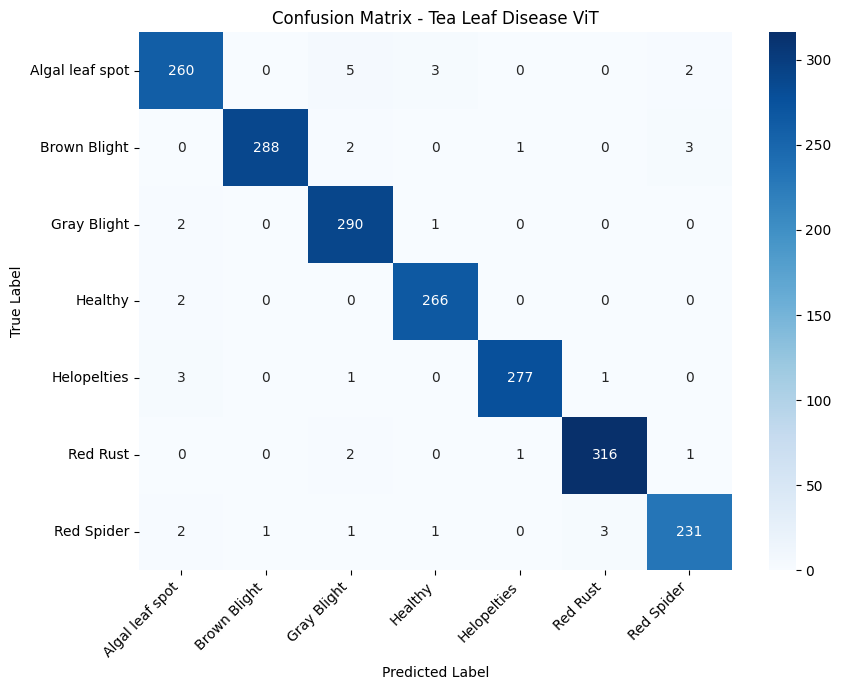

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tea Leaf Disease ViT")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "/content/tea_vit_classification_report.csv"
)

print("Classification report saved successfully.")
print(report_df)

Classification report saved successfully.
                 precision    recall  f1-score      support
Algal leaf spot   0.966543  0.962963  0.964750   270.000000
Brown Blight      0.996540  0.979592  0.987993   294.000000
Gray Blight       0.963455  0.989761  0.976431   293.000000
Healthy           0.981550  0.992537  0.987013   268.000000
Helopelties       0.992832  0.982270  0.987522   282.000000
Red Rust          0.987500  0.987500  0.987500   320.000000
Red Spider        0.974684  0.966527  0.970588   239.000000
accuracy          0.980671  0.980671  0.980671     0.980671
macro avg         0.980443  0.980164  0.980257  1966.000000
weighted avg      0.980786  0.980671  0.980681  1966.000000


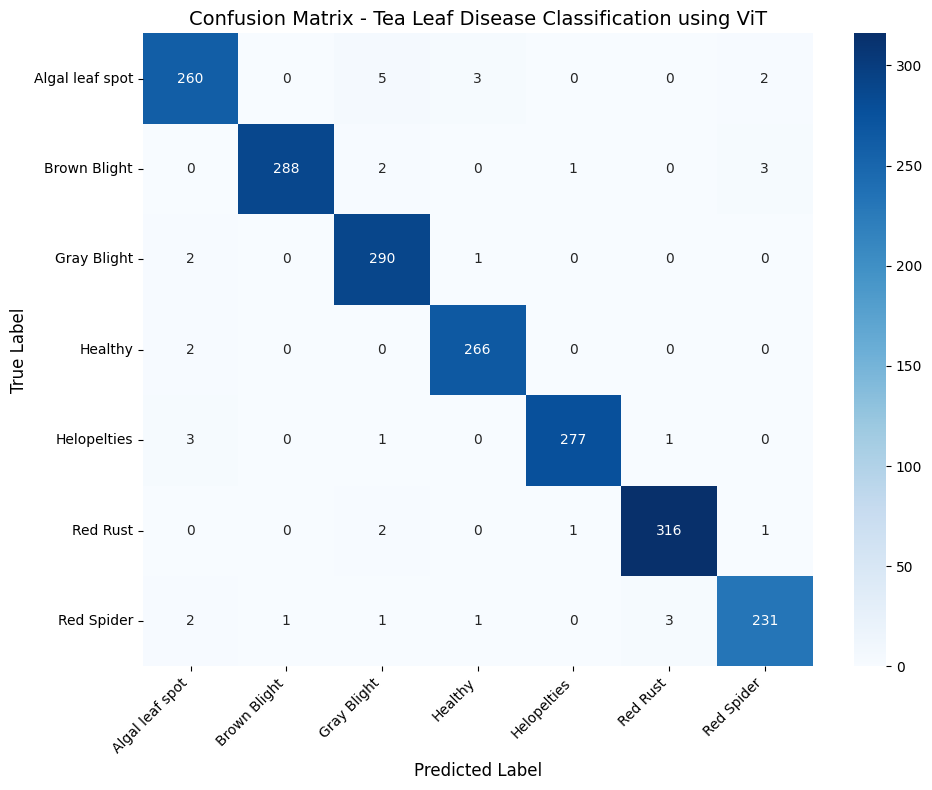

Confusion matrix saved successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Tea Leaf Disease Classification using ViT", fontsize=14)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "/content/tea_vit_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully.")

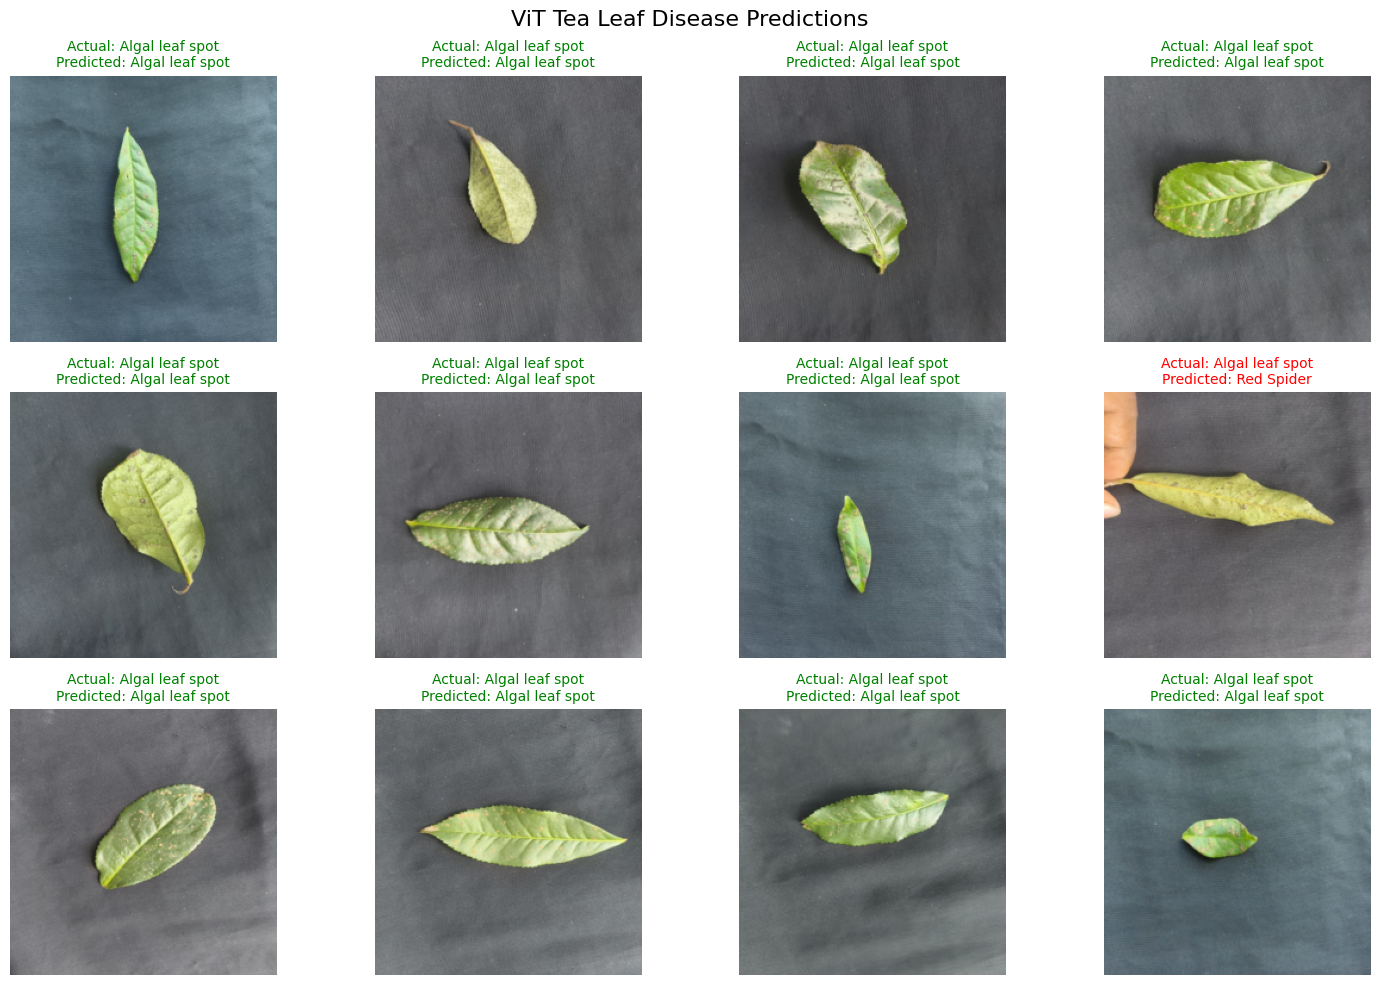

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

# Get one batch from test set
images, labels = next(iter(test_loader))

images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)
    predictions = torch.argmax(outputs, dim=1)

# Show first 12 images
plt.figure(figsize=(15, 10))

for i in range(min(12, len(images))):
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    actual = test_dataset.classes[labels[i].item()]
    predicted = test_dataset.classes[predictions[i].item()]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)

    title_color = "green" if actual == predicted else "red"

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color=title_color,
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "ViT Tea Leaf Disease Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(all_labels, all_predictions)

print("Per-Class Accuracy")
print("=" * 40)

for i, class_name in enumerate(test_dataset.classes):
    class_total = cm[i].sum()
    class_correct = cm[i, i]

    accuracy = 100 * class_correct / class_total

    print(f"{class_name:<20} : {accuracy:.2f}%")

Per-Class Accuracy
Algal leaf spot      : 96.30%
Brown Blight         : 97.96%
Gray Blight          : 98.98%
Healthy              : 99.25%
Helopelties          : 98.23%
Red Rust             : 98.75%
Red Spider           : 96.65%


In [ ]:
# Create final per-class results table

final_results = report_df.loc[
    test_dataset.classes,
    ["precision", "recall", "f1-score", "support"]
].copy()

final_results.columns = [
    "Precision",
    "Recall",
    "F1-Score",
    "Support"
]

# Convert metrics to percentages
final_results["Precision"] *= 100
final_results["Recall"] *= 100
final_results["F1-Score"] *= 100

final_results = final_results.round(2)

print("FINAL ViT MODEL RESULTS")
print("=" * 70)
print(final_results)

print("\nOverall Test Accuracy:", f"{test_accuracy:.2f}%")
print(
    "Macro F1-Score:",
    f"{report_df.loc['macro avg', 'f1-score'] * 100:.2f}%"
)
print(
    "Weighted F1-Score:",
    f"{report_df.loc['weighted avg', 'f1-score'] * 100:.2f}%"
)

# Save results
final_results.to_csv(
    "/content/tea_vit_final_results.csv"
)

print("\nResults saved to:")
print("/content/tea_vit_final_results.csv")

FINAL ViT MODEL RESULTS
                 Precision  Recall  F1-Score  Support
Algal leaf spot      96.65   96.30     96.47    270.0
Brown Blight         99.65   97.96     98.80    294.0
Gray Blight          96.35   98.98     97.64    293.0
Healthy              98.15   99.25     98.70    268.0
Helopelties          99.28   98.23     98.75    282.0
Red Rust             98.75   98.75     98.75    320.0
Red Spider           97.47   96.65     97.06    239.0

Overall Test Accuracy: 98.07%
Macro F1-Score: 98.03%
Weighted F1-Score: 98.07%

Results saved to:
/content/tea_vit_final_results.csv


In [ ]:
import os
import torch

# Create results folder
results_dir = "/content/tea_vit_results"
os.makedirs(results_dir, exist_ok=True)

# Save best model
torch.save(
    model.state_dict(),
    os.path.join(results_dir, "best_tea_vit.pth")
)

# Copy final results
final_results.to_csv(
    os.path.join(results_dir, "classification_results.csv")
)

# Save confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tea Leaf Disease Classification using ViT")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("All final results saved in:")
print(results_dir)

print("\nFiles:")
for file in os.listdir(results_dir):
    print("-", file)

All final results saved in:
/content/tea_vit_results

Files:
- classification_results.csv
- confusion_matrix.png
- best_tea_vit.pth


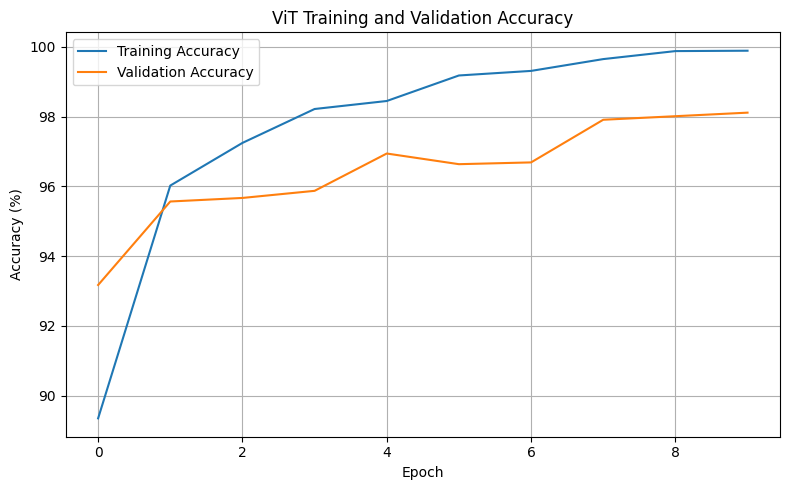

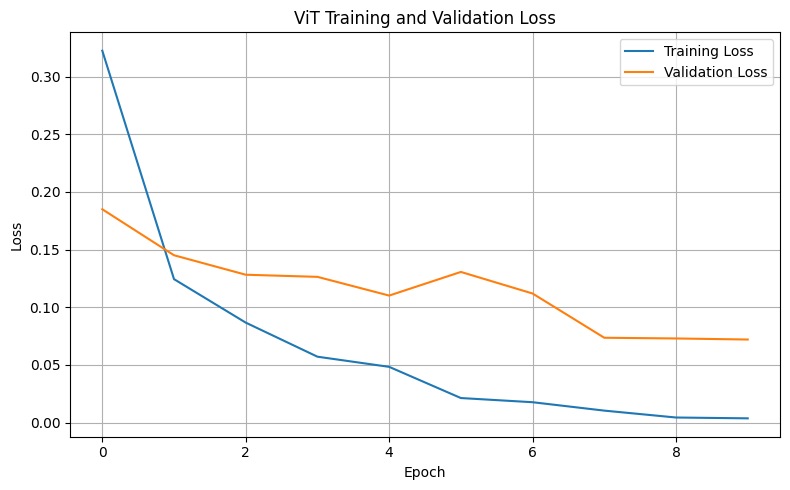

Training curves saved successfully.


In [ ]:
import matplotlib.pyplot as plt
import os

results_dir = "/content/tea_vit_results"

# Accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ViT Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "accuracy_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Loss curve
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "loss_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Training curves saved successfully.")